In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math
import os
import random
import trimesh

import torch
from torch.utils.data import DataLoader

from shapenet_dataset import ShapeNetDataset

# autoreload py
%load_ext autoreload
%autoreload 2

In [2]:
# pointcloud visualizer
def plot_pointclouds(pc_list):
    n = len(pc_list)
    n_cols = 4
    n_rows = math.ceil(n / n_cols)

    fig = plt.figure(figsize=(2 * n_cols, 2 * n_rows))
    fig.patch.set_facecolor('white')

    for i, (model_id, points) in enumerate(pc_list):
        ax = fig.add_subplot(n_rows, n_cols, i + 1, projection='3d')

        # convert to numpy if tensor
        if hasattr(points, "cpu"):
            points = points.cpu().numpy()

        ax.scatter(points[:, 0],points[:, 2],points[:, 1],s=2,c='dodgerblue',alpha=0.8)

        ax.set_title(f"ID: {str(model_id)[:8]}", fontsize=8)
        ax.set_axis_off()
        ax.set_box_aspect([1, 1, 1])

    # hide unused subplots
    total_plots = n_rows * n_cols
    for j in range(n, total_plots):
        ax = fig.add_subplot(n_rows, n_cols, j + 1, projection='3d')
        ax.set_axis_off()

    plt.subplots_adjust(wspace=0, hspace=0.1)
    plt.show()

# Autoencoder

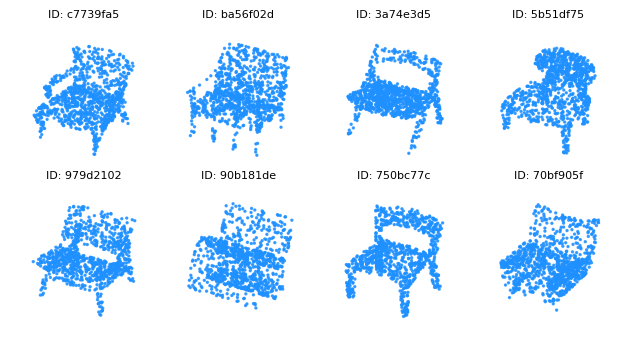

In [3]:
dataset = ShapeNetDataset(data_dir='/ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/', object_class='03001627', num_points=1024)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list)
    break

In [ ]:
from model import PointCloudAE

model = PointCloudAE(z_dim=128, num_points=2048).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100
for epoch in range(num_epochs):
    